This notebook contains all code required for training all three classifiers considered: MLP, random forest and gradient boosting.

This can be done through manual training, or through an automated grid search. Both methods are outlined below.

In [1]:
from datetime import datetime
import joblib
from pathlib import Path

from ml_baselines.features import feature_importance, plot_importance
from ml_baselines.modelling.train import train_baseline_model, train_baseline_model_grid_search
from ml_baselines.modelling.cv_analysis import load_cv_results, get_top_params, plot_param_effects

from ml_baselines.config import Config
cfg = Config()

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [2]:
site = "MHD"
model_type = cfg.model_type

### Manual Train

In [3]:
# define model hyperparameters
mlp_params_dict = {
               'hidden_layer_sizes': (64,),
               'activation': 'relu',
               'solver': 'adam',
               'alpha': 2.5,
               'batch_size': 32,
               'learning_rate': "constant",
               'learning_rate_init': 0.0001,
               'max_iter': 500,
               'shuffle': True,
               'early_stopping': True,
               'validation_fraction': 0.15,
               'n_iter_no_change': 20,
}

random_forest_params_dict = {
               'n_estimators':100,
               'criterion': 'gini',
               'max_depth': 6,
               'min_samples_split': 15,
               'min_samples_leaf': 20,
               'max_features': 'sqrt',
               'bootstrap': True,
               'n_jobs':-1,
               'max_samples': 0.8
}

gradient_boosting_params_dict = {
                   'loss': 'log_loss',
                   'learning_rate': 0.05,
                   'n_estimators': 100,
                   'subsample': 0.6,
                   'criterion': 'friedman_mse',
                   'min_samples_split': 10,
                   'min_samples_leaf': 10,
                   'min_weight_fraction_leaf': 0.0,
                   'max_depth': 4,
                   'max_features': 'log2',
}

params_map = {
    "mlp": mlp_params_dict,
    "random_forest": random_forest_params_dict,
    "gradient_boosting": gradient_boosting_params_dict
}

In [4]:
# define train kwargs
train_kwargs = {
        'balance': 0.3,
        'balance_method': 'random',
        'undersample': 0,
        'sample_weights': 1.5,
        'normalise_inputs': True,
        'time_shift_hours': [6, 12, 18, 24],
        'prediction_threshold': 0.65
        }

# manual train
model, X, y, extra_info = train_baseline_model(
                                site=site,
                                model_type=model_type,

                                balance=train_kwargs['balance'],
                                balance_method=train_kwargs['balance_method'],
                                undersample=train_kwargs['undersample'],
                                sample_weights=train_kwargs['sample_weights'],
                                normalise_inputs=train_kwargs['normalise_inputs'],
                                time_shift_hours=train_kwargs['time_shift_hours'],
                                prediction_threshold=train_kwargs['prediction_threshold'],

                                model_params=params_map[model_type],

                                return_scores=True,
                                return_scaler=True,
                                return_inputs=True,

                                save_model=False,
                                save_suffix="",
                                evaluate_on_test=False,

                                verbose=True
                                )

Training MLP model for site: MHD
... loading train data for site: MHD, period: 2017-2019
... balancing dataset to target baseline ratio of 0.3
... calculating sample weights
Assigning baseline sample weight: 1.500 and non-baseline sample weight: 1.000
Number of training points: 9463
Number of baseline points: 2839 (30.0%)
... loading validation data for site: MHD, period: 2020-2020
... normalising inputs
Preprocessing time: 8.1s
... fitting
Fit time: 16.4s
... predicting
Using custom prediction threshold of 0.65 instead of default 0.5
Evaluation scores:
The training dataset was balanced or undersampled. Providing scores also on the original unbalanced training set
Precision on Training Set = 0.857
Precision on the original Training Set = 0.780
Precision on Validation Set = 0.702
Recall on Training Set = 0.656
Recall on the original Training Set = 0.656
Recall on Validation Set = 0.567
F1 Score on Training Set = 0.743
F1 Score on the original Training Set = 0.713
F1 Score on Validation 

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance by Variable'}, xlabel='Mean Accuracy Drop (%)'>)

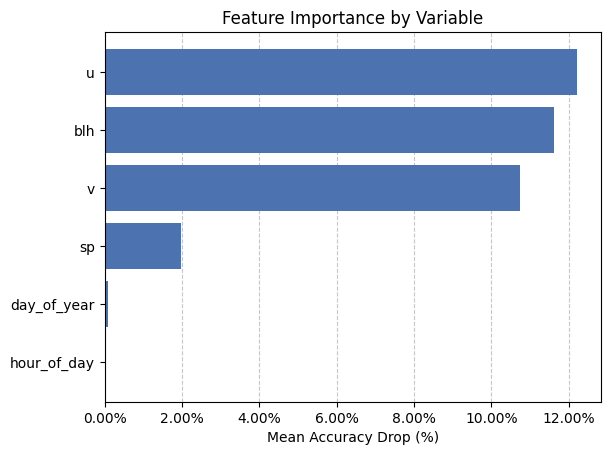

In [5]:
importance = feature_importance(model, X, y, use_permutation=True)
plot_importance(importance)

In [6]:
# Save model
save_suffix = 'test'

info_to_save = {"scores": extra_info['scores'], "scaler": extra_info['scaler'], 
                "model_inputs": {"model_params": params_map[model_type], "balance": train_kwargs['balance'], "balance_method": train_kwargs['balance_method'], 
                                 "undersample": train_kwargs['undersample'], "sample_weights": train_kwargs['sample_weights'], 
                                 "normalise_inputs": train_kwargs['normalise_inputs'], "time_shift_hours": train_kwargs['time_shift_hours'], 
                                 "prediction_threshold": train_kwargs['prediction_threshold']}}
to_save  = {
    "model": model,
    "info": info_to_save,
}

joblib.dump(to_save, Path(cfg.models_path) / f"{site}" / f"{model_type}_model_{datetime.now().strftime('%Y-%m-%d_%H-%M')}{f'_{save_suffix}' if save_suffix is not None else ''}.joblib")

['C:\\Users\\kirst\\OneDrive\\Kirstin\\Uni\\Year4\\MSciProject\\final_code\\ml-baselines\\models\\MHD\\mlp_model_2026-06-01_18-13_test.joblib']

### Grid Search

In [7]:
# define hyperparameters to test
mlp_param_grid = {
        'activation': ['relu'],
        'solver': ['adam'],
        'alpha': [1],
        'batch_size': [32],
        'hidden_layer_sizes': [(128,)],
        'learning_rate': ["constant"],
        'learning_rate_init': [0.0001],
        'early_stopping': [True],
        'shuffle': [True],
        'max_iter': [500],
        }

random_forest_param_grid = {
        'n_estimators': [100,],
        'criterion': ['gini',],
        'max_depth': [10,],
        'min_samples_split': [10],
        'max_features': ['sqrt',],
        'bootstrap': [True],
        'n_jobs': [-1]
        }

gradient_boosting_params_grid = {
        'loss': ['log_loss'],
        'learning_rate': [0.05],
        'n_estimators': [100],
        'subsample': [0.7],
        'criterion': ['friedman_mse'],
        'min_samples_split': [5],
        'min_samples_leaf': [5],
        'max_depth': [5, 8, 10],
        'max_features': ['log2', 'sqrt'],
        }

params_grid_map = {
    "mlp": mlp_param_grid,
    "random_forest": random_forest_param_grid,
    "gradient_boosting": gradient_boosting_params_grid
}

# define train kwargs to test
data_kwargs = {
        'balance': [-1, 0.3],
        'sample_weights': [None, 1.5],
        'normalise_inputs': [False],
        'time_shift_hours': [[6,12,18,24]],     
        }
validation_keys = ["time_shift_hours", "balance"] # keys that should also be forwarded when loading the validation set i.e. kwargs that affect the feature representation
prediction_thresholds = [0.7, 0.75, 0.8, 0.85]

In [8]:
# run a grid search
grid_search = train_baseline_model_grid_search(
                                        site=site,
                                        model_type=model_type,

                                        scoring=["precision", "f1", "recall"],
                                        param_grid=params_grid_map[model_type],
                                        data_kwargs=data_kwargs,
                                        validation_keys=validation_keys,
                                        prediction_thresholds=prediction_thresholds,

                                        return_cv_scores=True,
                                        save_cv_scores=True,
                                        save_suffix=""
                                        )

Running grid search for MLP model for site: MHD

Run 1/4 — data kwargs: {'balance': -1, 'sample_weights': None, 'normalise_inputs': False, 'time_shift_hours': [6, 12, 18, 24]}
... loading train data for site: MHD, period: 2017-2019
... loading validation data for site: MHD, period: 2020-2020
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Best parameters found:  {'activation': 'relu', 'alpha': 1, 'batch_size': 32, 'early_stopping': True, 'hidden_layer_sizes': (128,), 'learning_rate': 'constant', 'learning_rate_init': 0.0001, 'max_iter': 500, 'shuffle': True, 'solver': 'adam'}
Best score (default threshold 0.5):  0.7367424242424242
  Threshold 0.50: precision = 0.701
  Threshold 0.70: precision = 0.701
  Threshold 0.75: precision = 0.701
  Threshold 0.80: precision = 0.701
  Threshold 0.85: precision = 0.701

Run 2/4 — data kwargs: {'balance': -1, 'sample_weights': 1.5, 'normalise_inputs': False, 'time_shift_hours': [6, 12, 18, 24]}
... loading train data for site: MHD, perio

In [9]:
cv_df = load_cv_results(site=site, save_suffix="", model_type=model_type)
get_top_params(cv_df)

,param_activation,param_alpha,param_batch_size,param_early_stopping,param_hidden_layer_sizes,param_learning_rate,param_learning_rate_init,param_max_iter,param_shuffle,param_solver,param_data_balance,param_data_sample_weights,param_data_normalise_inputs,param_data_time_shift_hours,mean_test_f1,mean_train_f1,rank_test_f1
0,relu,1,32,True,"(128,)",constant,0.0001,500,True,adam,0.3,1.5,False,"[6, 12, 18, 24]",0.714190,0.743637,1
1,relu,1,32,True,"(128,)",constant,0.0001,500,True,adam,0.3,1.5,False,"[6, 12, 18, 24]",0.714190,0.743637,1
2,relu,1,32,True,"(128,)",constant,0.0001,500,True,adam,0.3,1.5,False,"[6, 12, 18, 24]",0.713902,0.743637,3
3,relu,1,32,True,"(128,)",constant,0.0001,500,True,adam,0.3,1.5,False,"[6, 12, 18, 24]",0.713710,0.743637,4
4,relu,1,32,True,"(128,)",constant,0.0001,500,True,adam,0.3,1.5,False,"[6, 12, 18, 24]",0.680704,0.743637,5


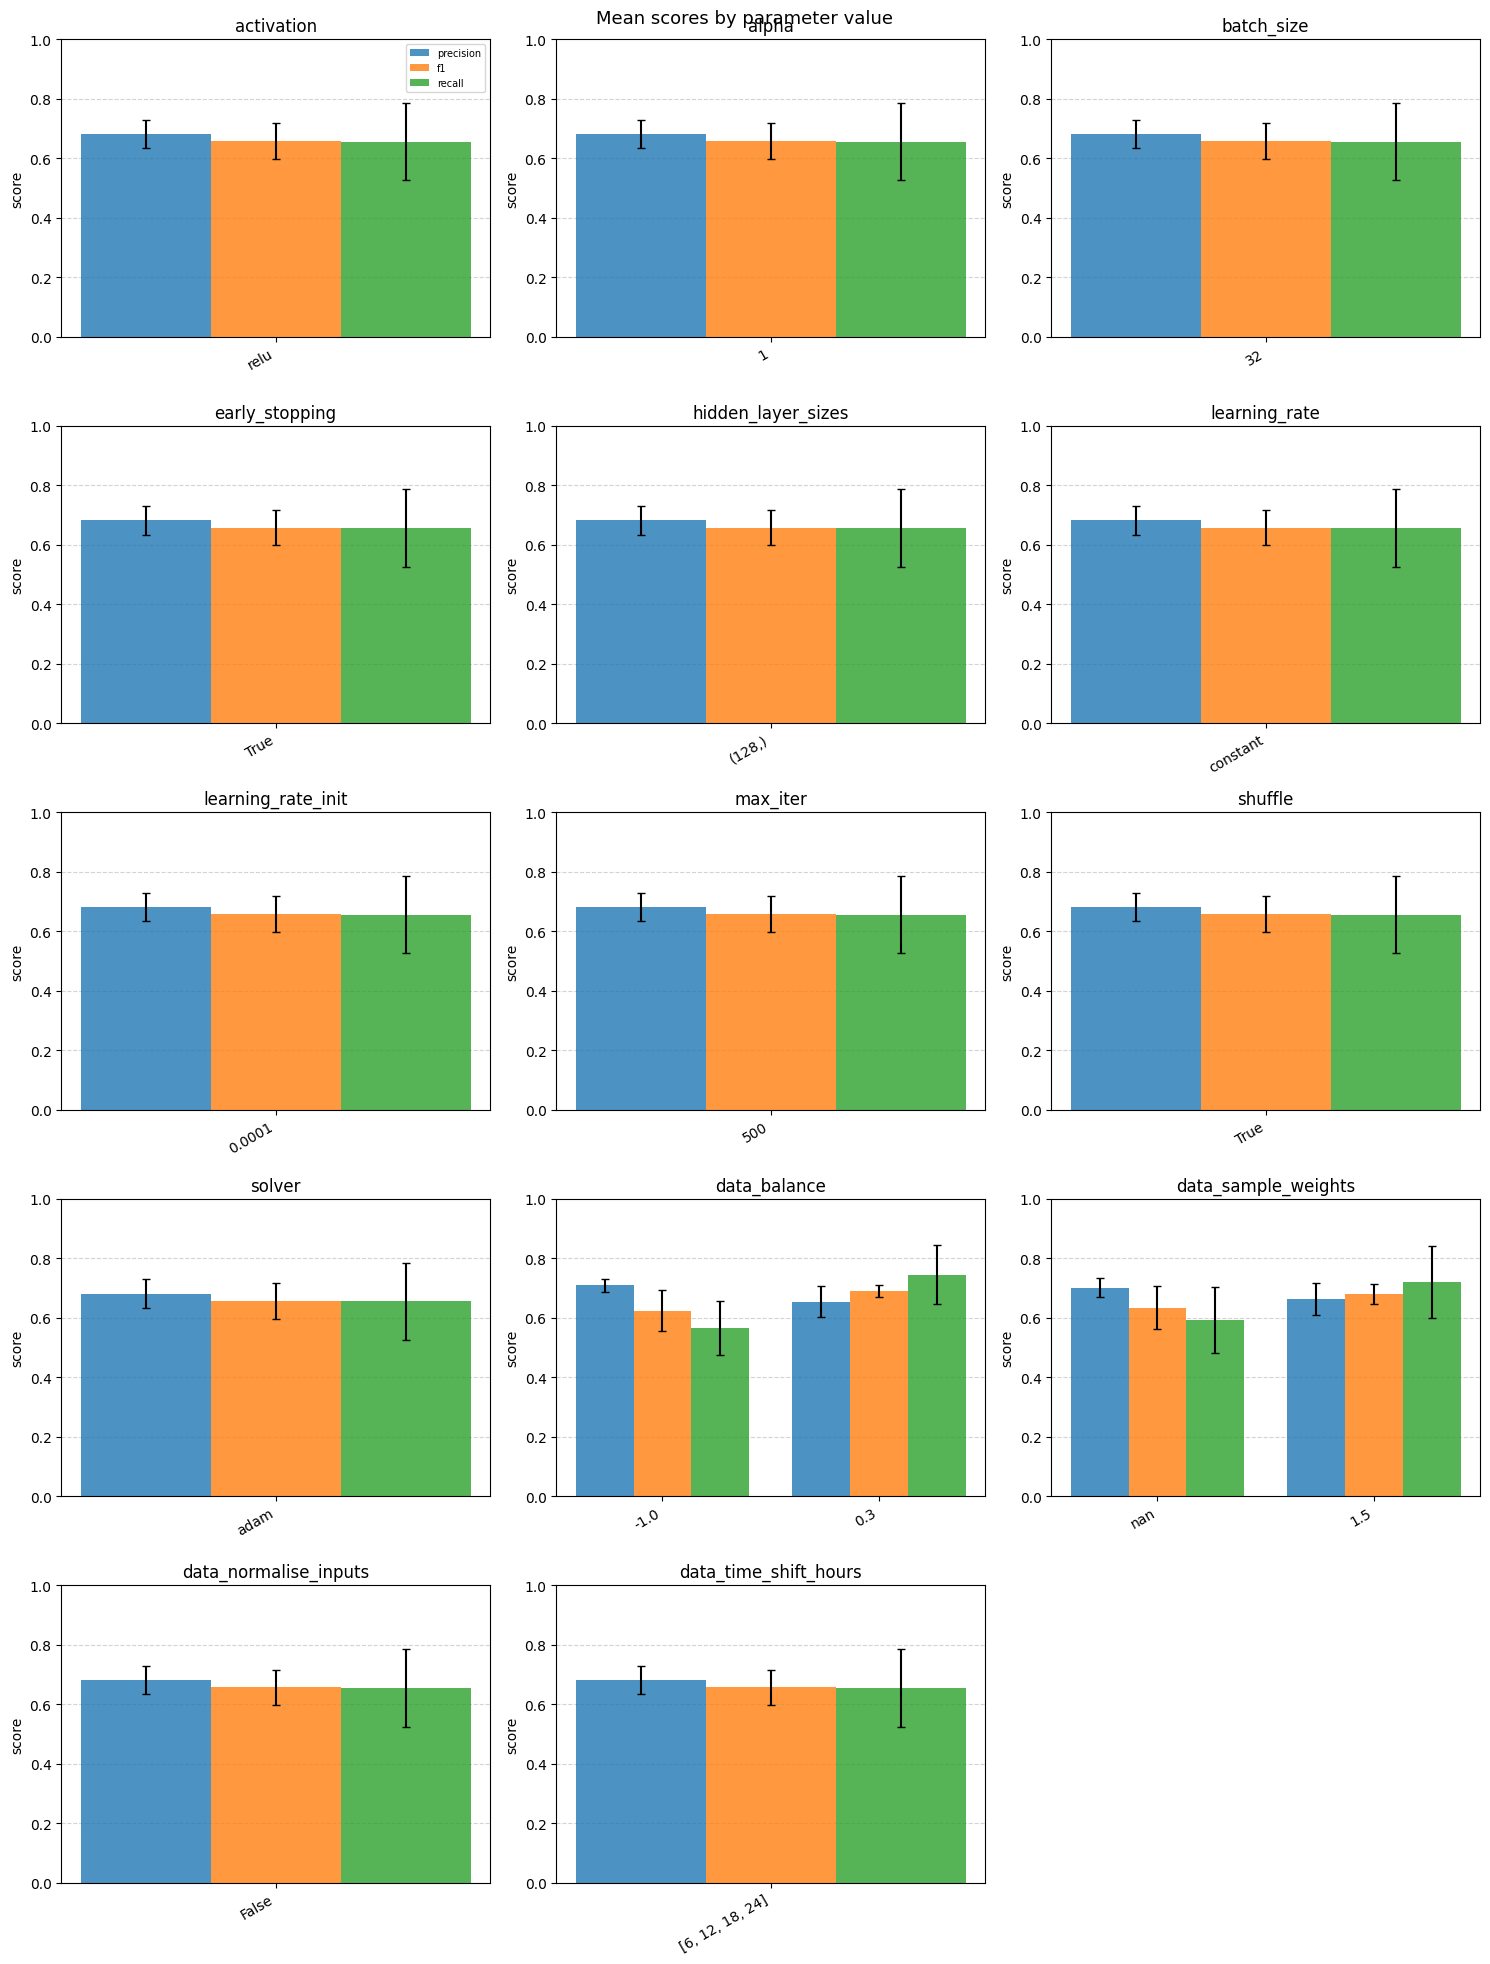

In [10]:
fig, axes = plot_param_effects(cv_df, metric='all')